In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("listings.csv")

df.head()

,locality,property_type,subtype,price_eur,type_of_sale,num_rooms,living_area_m2,fully_equipped_kitchen,furnished,terrace,terrace_area_m2,garden,garden_area_m2,land_surface_m2,num_facades,swimming_pool,state_of_building
0,9000 Gent,House,Mixed Building,2200000.0,for sale,6.0,1285.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fully renovated
1,1350 Orp-le-Grand,House,Residence,488652.0,for sale,4.0,219.0,NaN,NaN,0.0,NaN,1.0,1127.0,1221.0,3.0,NaN,New
2,6560 Erquelinnes,House,Villa,365000.0,for sale,4.0,281.0,NaN,NaN,1.0,NaN,1.0,NaN,5639.0,4.0,NaN,NaN
3,8470 Gistel,House,Residence,NaN,for sale,4.0,238.0,NaN,NaN,1.0,NaN,1.0,NaN,820.0,NaN,NaN,Excellent
4,5570 Felenne,House,Cottage,118000.0,for sale,2.0,110.0,NaN,0.0,1.0,NaN,1.0,NaN,733.0,NaN,NaN,NaN


STEP 2 : DATA ANALYSIS

In [4]:
#How many rows and columns 
df = df.drop_duplicates()

In [5]:
#Data cleaning

df = df[(df["living_area_m2"] > 20) & (df["price_eur"] > 10000) &  (df["num_rooms"] > 0)]

#Spliting postal code and municipality 
df[["postal_code", "municipality"]] = df["locality"].str.split(" ", n=1, expand=True)
df["postal_code"] = df["postal_code"].astype(int)

df = df.drop(columns=["locality"])

#No garden no m2/No terrace no m2
df.loc[df['garden'] == 0, 'garden_area_m2'] = 0
df.loc[df['terrace'] == 0, 'terrace_area_m2'] = 0

#Remove localities with less than 10 properties
df= df.groupby("municipality").filter(lambda x: len(x) > 10)

df["fully_equipped_kitchen"] = df["fully_equipped_kitchen"].fillna(0)
df["swimming_pool"] = df["swimming_pool"].fillna(0)
df["furnished"] = df["furnished"].fillna(0)
df["land_surface_m2"] = df["land_surface_m2"].fillna(0)
df["land_surface_m2"] = df["land_surface_m2"].fillna(0)
df["garden_area_m2"] = df["garden_area_m2"].fillna(0)
df["terrace_area_m2"] = df["terrace_area_m2"].fillna(0)
df["garden"] = df["garden"].fillna(0)
df["terrace"] = df["terrace"].fillna(0)
df['num_facades'] = df['num_facades'].fillna(df['num_facades'].mean())



#Creating wallonie,bx & flandre columns
df["wallonie_bx"] = df["postal_code"].between(1000, 1499) | df["postal_code"].between(4000, 6999) | df["postal_code"].between(7000, 7999)
df["wallonie_bx"] = df["wallonie_bx"].astype(int)

df["flandre"] = df["postal_code"].between(1500, 3499) | df["postal_code"].between(8000, 9999)
df["flandre"] = df["flandre"].astype(int)

df.head()

,property_type,subtype,price_eur,type_of_sale,num_rooms,living_area_m2,fully_equipped_kitchen,furnished,terrace,terrace_area_m2,garden,garden_area_m2,land_surface_m2,num_facades,swimming_pool,state_of_building,postal_code,municipality,wallonie_bx,flandre
0,House,Mixed Building,2200000.0,for sale,6.0,1285.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.707955,0.0,Fully renovated,9000,Gent,0,1
1,House,Residence,488652.0,for sale,4.0,219.0,0.0,0.0,0.0,0.0,1.0,1127.0,1221.0,3.000000,0.0,New,1350,Orp-le-Grand,1,0
2,House,Villa,365000.0,for sale,4.0,281.0,0.0,0.0,1.0,0.0,1.0,0.0,5639.0,4.000000,0.0,NaN,6560,Erquelinnes,1,0
7,Apartment,Apartment,250000.0,for sale,1.0,70.0,1.0,0.0,1.0,6.0,0.0,0.0,0.0,2.000000,0.0,Normal,1420,Braine-l'Alleud,1,0
8,House,Residence,545000.0,for sale,5.0,263.0,0.0,0.0,1.0,0.0,1.0,90.0,195.0,2.707955,0.0,Normal,1780,Wemmel,0,1


In [6]:
#What is the correlation between the variables and the price? (Why might that be?)

df.corr(numeric_only=True)["price_eur"].sort_values(ascending=False)

price_eur                 1.000000
living_area_m2            0.622526
num_rooms                 0.475509
swimming_pool             0.253356
land_surface_m2           0.243842
num_facades               0.203035
terrace_area_m2           0.202264
garden                    0.162105
garden_area_m2            0.144702
terrace                   0.123573
fully_equipped_kitchen    0.066548
flandre                   0.047144
furnished                 0.019992
wallonie_bx              -0.035950
postal_code              -0.168698
Name: price_eur, dtype: float64

Which variables have the greatest influence on the price : Living Area m2

Which variables have the least influence on the price? Furnished or no



In [7]:
# How are variables correlated to each other? (Why?)

df.corr(numeric_only=True).drop(index=["price_eur"], columns=["fully_equipped_kitchen", "price_eur"]) * 100

,num_rooms,living_area_m2,furnished,terrace,terrace_area_m2,garden,garden_area_m2,land_surface_m2,num_facades,swimming_pool,postal_code,wallonie_bx,flandre
num_rooms,100.000000,71.331956,-0.005187,2.546394,8.373366,26.777899,10.004695,20.014415,17.243531,10.267185,2.038807,3.342679,-2.999498
living_area_m2,71.331956,100.000000,-2.472893,1.292909,15.164957,26.530279,14.852927,28.462240,23.422370,19.920139,1.357203,-0.802356,0.397435
fully_equipped_kitchen,4.986192,5.103775,2.065476,14.641653,9.754916,3.816374,3.267614,1.087278,-1.514505,4.105922,-4.827693,20.249904,-16.519397
furnished,-0.005187,-2.472893,100.000000,2.074274,0.903685,-4.314390,2.530135,1.237915,0.999937,5.427123,5.859205,-0.301539,1.680864
terrace,2.546394,1.292909,2.074274,100.000000,21.330990,9.872694,3.064571,1.314364,-0.093181,6.808020,-4.742393,-1.157881,0.922558
terrace_area_m2,8.373366,15.164957,0.903685,21.330990,100.000000,5.269379,8.618376,7.686581,7.286320,13.877302,-3.704317,8.432284,-7.516459
garden,26.777899,26.530279,-4.314390,9.872694,5.269379,100.000000,8.699980,15.618468,26.326493,11.765539,12.349707,-4.754905,3.630111
garden_area_m2,10.004695,14.852927,2.530135,3.064571,8.618376,8.699980,100.000000,55.746831,10.653333,10.735480,0.071456,3.407126,-2.647349
land_surface_m2,20.014415,28.462240,1.237915,1.314364,7.686581,15.618468,55.746831,100.000000,23.358704,17.031558,1.043788,0.209237,-0.845287
num_facades,17.243531,23.422370,0.999937,-0.093181,7.286320,26.326493,10.653333,23.358704,100.000000,18.482984,5.554599,-4.570549,2.127677


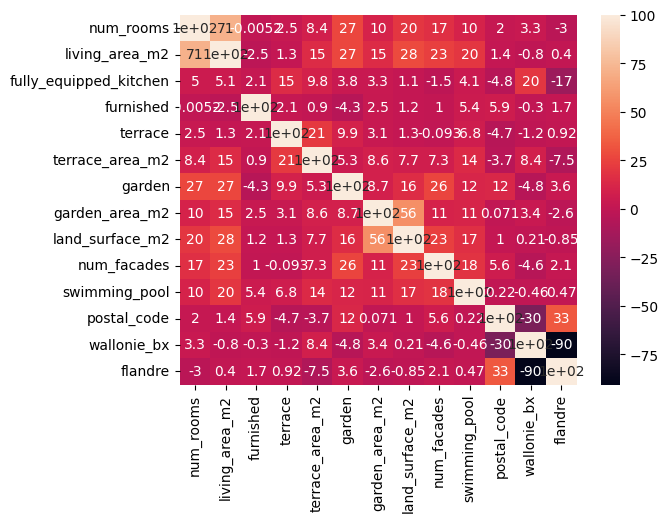

In [8]:
b = df.corr(numeric_only=True).drop(index=["price_eur"], columns=["fully_equipped_kitchen", "price_eur"]) * 100

sns.heatmap(b, annot=True)
plt.show()

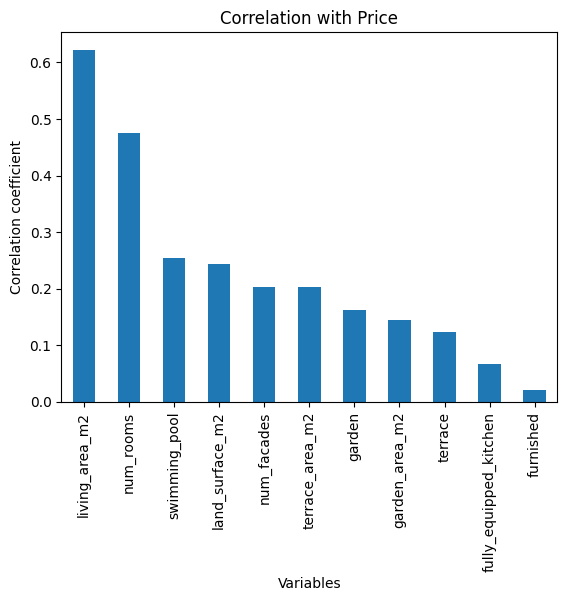

In [9]:
#Correlation with price graph 

a = df.corr(numeric_only=True)["price_eur"].drop(["price_eur","wallonie_bx","postal_code", "flandre"]).sort_values(ascending=False)
a.plot(kind="bar")
plt.title("Correlation with Price")
plt.xlabel("Variables")
plt.ylabel("Correlation coefficient")
plt.show()


In [10]:
# How many quantitative variables are there?

len(df.select_dtypes(include="number").columns)

15

In [11]:
# How many quantitative variables are there?

len(df.select_dtypes(include="object").columns)

/var/folders/rc/3j14_by95fd8x5qx1hctj6r80000gn/T/ipykernel_43158/1742097402.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  len(df.select_dtypes(include="object").columns)


5

In [12]:
#How would you transform these values into numerical values?

#pd.get_dummies(df, columns=["locality", "property_type", "subtype", "type_of_sale", "state_of_building"])


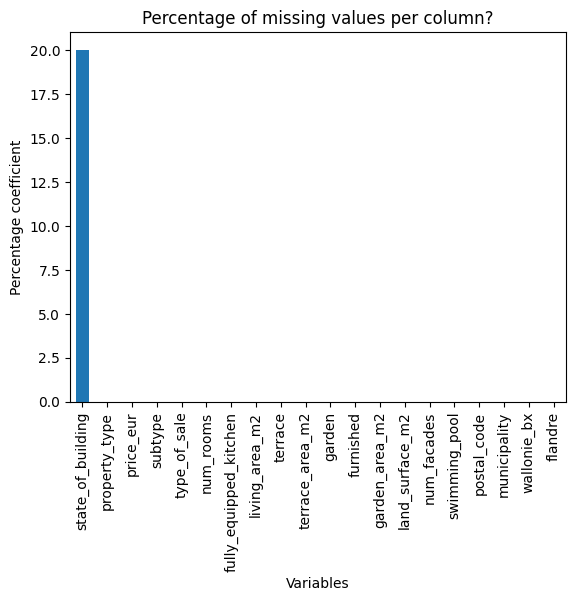

In [13]:
#Percentage of missing values per column?
missings = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missings.plot(kind="bar")
plt.title("Percentage of missing values per column?")
plt.xlabel("Variables")
plt.ylabel("Percentage coefficient")
plt.show()

In [14]:
#Creating Variables 

df["price_per_m2"] = df["price_eur"] / df["living_area_m2"]
df["price_per_m2"].mean()

np.float64(2770.1483708502346)

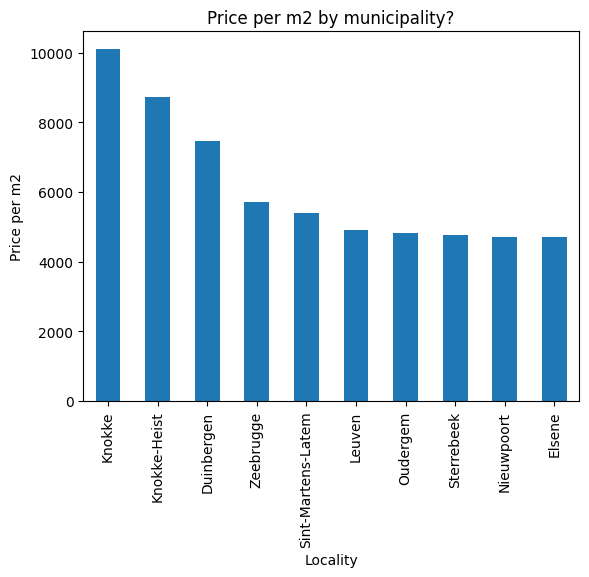

In [15]:
price_per_m2 = df.groupby("municipality")["price_per_m2"].mean().sort_values(ascending=False).head(10)

price_per_m2.plot(kind="bar")
plt.title("Price per m2 by municipality?")
plt.xlabel("Locality")
plt.ylabel("Price per m2")
plt.show()

STEP 3 : DATA INTERPRETATION

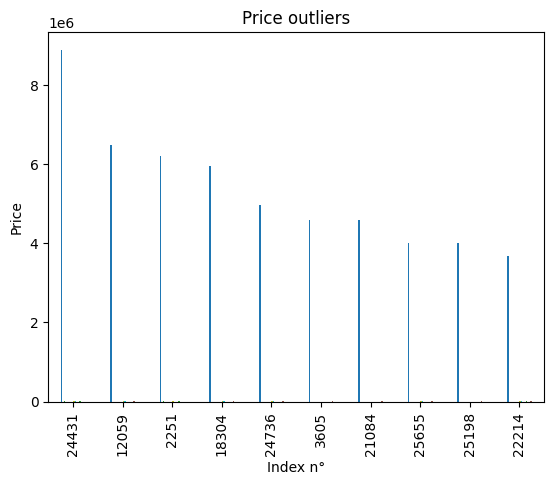

In [16]:
#Plot the outliers 
outliers_price = df.sort_values("price_eur", ascending=False).head(10)

outliers_price.plot(kind="bar")
plt.title("Price outliers")
plt.xlabel("Index n°")
plt.ylabel("Price")
plt.legend().remove()
plt.show()

In [17]:
#Which variables would you delete and why ?

"""  
df["garden_area_m2"] & df["terrace_area_m2"]

Too many missing values  """

'  \ndf["garden_area_m2"] & df["terrace_area_m2"]\n\nToo many missing values  '

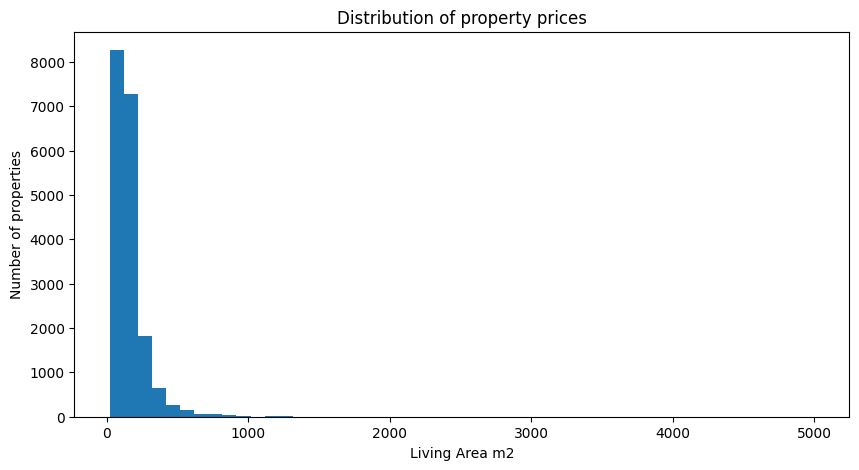

In [18]:
#Represent the number of properties according to their surface using a histogram
plt.figure(figsize=(10,5))
plt.hist(df["living_area_m2"], bins=50)
plt.title("Distribution of property prices")
plt.xlabel("Living Area m2")
plt.ylabel("Number of properties")
plt.show()

In [19]:
#What are the most expensive municipalities in Belgium? (Average price, median price, price per square meter)

municipality_be = df.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
municipality_be.sort_values("avg_price", ascending=False).head(10)

,avg_price,median_price,avg_price_per_m2
municipality,,,
Knokke,1.090372e+06,795000.0,10103.208053
Kraainem,1.069244e+06,995000.0,4254.234382
Sterrebeek,1.035171e+06,849000.0,4772.550109
Sint-Pieters-Woluwe,8.885434e+05,695000.0,4362.579348
Tervuren,8.771668e+05,721000.0,3519.243404
Knokke-Heist,8.745557e+05,865000.0,8723.075616
Sint-Genesius-Rode,8.720364e+05,685000.0,3453.203381
La Hulpe,8.378750e+05,557500.0,4053.003628
Ukkel,8.163737e+05,595000.0,4479.022304


In [20]:
#What are the most expensive municipalities in Wallonia? (Average price, median price, price per square meter)
wallonia = df[df["wallonie_bx"] == 1]

wallonia_bx = wallonia.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
wallonia_bx.sort_values("avg_price", ascending=False).head(10)


,avg_price,median_price,avg_price_per_m2
municipality,,,
Sint-Pieters-Woluwe,888543.352601,695000.0,4362.579348
La Hulpe,837875.000000,557500.0,4053.003628
Ukkel,816373.727273,595000.0,4479.022304
Lasne,797292.062500,722500.0,3251.456069
Elsene,786007.002801,599500.0,4701.416586
Les Bons Villers,712889.545455,382173.0,2375.037141
Grez-Doiceau,703144.523810,412500.0,3042.783754
Couillet,672152.526316,205000.0,1324.936266
Etterbeek,660650.384615,492500.0,4126.807054


In [21]:
#What are the most expensive municipalities in Flanders? (Average price, median price, price per square meter)

flanders = df[df["flandre"] == 1]

flandre = flanders.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
flandre.sort_values("avg_price", ascending=False).head(10)

,avg_price,median_price,avg_price_per_m2
municipality,,,
Knokke,1.090372e+06,795000.0,10103.208053
Kraainem,1.069244e+06,995000.0,4254.234382
Sterrebeek,1.035171e+06,849000.0,4772.550109
Tervuren,8.771668e+05,721000.0,3519.243404
Knokke-Heist,8.745557e+05,865000.0,8723.075616
Sint-Genesius-Rode,8.720364e+05,685000.0,3453.203381
Overijse,7.981659e+05,629000.0,3188.751555
Hoeilaart,7.801074e+05,625000.0,2649.233495
Schilde,7.798060e+05,643130.5,3405.632724


In [22]:
#What are the less expensive municipalities in Belgium? (Average price, median price, price per square meter)

municipality_be = df.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
municipality_be.sort_values("avg_price", ascending=True).head(10)


,avg_price,median_price,avg_price_per_m2
municipality,,,
Blaimont,87190.476190,65500.0,1543.377759
Hastière-Lavaux,91721.428571,86950.0,1524.771195
Colfontaine,145835.714286,139500.0,992.641709
Marchienne-au-Pont,150799.727273,149999.0,988.482517
Ougrée,160512.500000,177000.0,1648.714505
Houdeng-Aimeries,164090.727273,159000.0,1170.943445
Quaregnon,172267.588235,165000.0,1138.367792
Montignies-sur-Sambre,174299.930233,170000.0,1389.298262
Farciennes,175907.920000,169000.0,1412.920818


In [23]:
#What are the less expensive municipalities in Wallonia? (Average price, median price, price per square meter)

wallonia = df[df["wallonie_bx"] == 1]

wallonia_bx = wallonia.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
wallonia_bx.sort_values("avg_price", ascending=True).head(10)

,avg_price,median_price,avg_price_per_m2
municipality,,,
Blaimont,87190.476190,65500.0,1543.377759
Hastière-Lavaux,91721.428571,86950.0,1524.771195
Colfontaine,145835.714286,139500.0,992.641709
Marchienne-au-Pont,150799.727273,149999.0,988.482517
Ougrée,160512.500000,177000.0,1648.714505
Houdeng-Aimeries,164090.727273,159000.0,1170.943445
Quaregnon,172267.588235,165000.0,1138.367792
Montignies-sur-Sambre,174299.930233,170000.0,1389.298262
Farciennes,175907.920000,169000.0,1412.920818


In [24]:
#What are the less expensive municipalities in Flanders? (Average price, median price, price per square meter)

flanders = df[df["flandre"] == 1]

flandre = flanders.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
flandre.sort_values("avg_price", ascending=True).head(10)

,avg_price,median_price,avg_price_per_m2
municipality,,,
Wervik,208313.896552,199000.0,1197.586880
Moorslede,222272.727273,165000.0,1748.990636
Menen,259394.285714,199000.0,1602.079626
Deurne,264048.148148,238000.0,2586.508080
Borgerhout,264604.347826,242000.0,2673.669116
Rekkem,269236.666667,289000.0,1690.475330
Bredene,272024.037037,249000.0,2474.914042
Zellik,274842.727273,259000.0,2913.655327
Merksem,282513.235294,264000.0,2553.956136
